In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Objective:**
- we use a simple polynomial function for the objective function with the goal being to find the minimum value... This function has one global minimum over the range we define it as well as one local minimum
- when we define the objective function, we must make sure that it returns a single real-value number to minimize. if we return a metric such as accuracy, we would have to return the negative of the accuracy to tell our model to find a better accuracy!. We can also return a dictionary where one of the keys must be "loss"

In [3]:
def objective(x):
    """ Objective function to minimize """

    # create the polynomial object
    f = np.poly1d([1, -2, -28, 28, 12, -26, 100])

    # return the value of the polynomial
    return f(x) * 0.05

Minimum of -219.8012 occurs at 4.8779


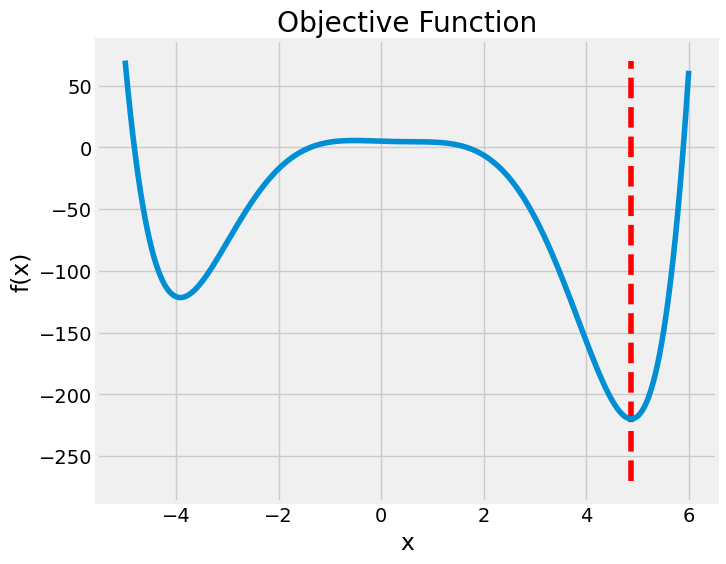

In [4]:
# space over which to evaluate the function is -5 to 6
x = np.linspace(-5, 6, 10000)
y = objective(x)

miny = min(y)
minx = x[np.argmin(y)]

# visualise the function
plt.figure(figsize = (8, 6))
plt.style.use('fivethirtyeight')
plt.title('Objective Function'); plt.xlabel('x'); plt.ylabel('f(x)')
plt.vlines(minx, min(y)- 50, max(y), linestyles = '--', colors = 'r')
plt.plot(x, y);

# Print out the minimum of the function and value
print('Minimum of %0.4f occurs at %0.4f' % (miny, minx))

**Domain:**
- the domain is the values of x over which we evaluate the function. first we can use a uniform distribution over the space our function is defined..

In [5]:
from hyperopt import hp

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [6]:
# create the domain space
space = hp.uniform('x', -5, 6)

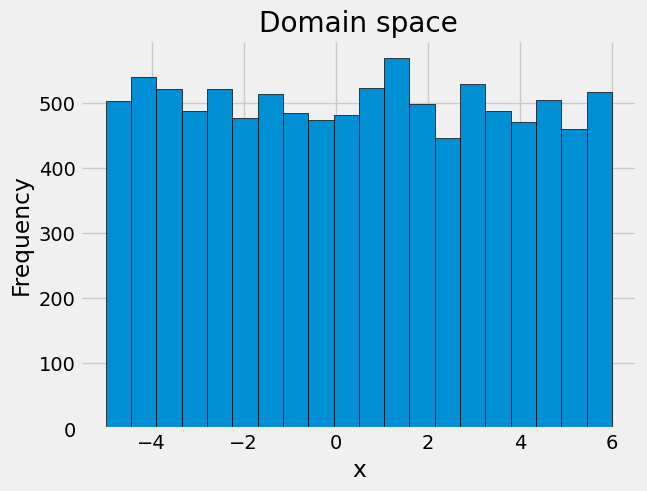

In [8]:
# we can draw samples from the space using a hyperopt utility. this is useful for visualising a distribution

from hyperopt.pyll.stochastic import sample

samples = []

# sample 10000 from the range

for _ in range(10000):
    samples.append(sample(space))

# histogram of the values
plt.hist(samples, bins=20, edgecolor='black');
plt.xlabel('x'); plt.ylabel('Frequency'); plt.title('Domain space');

when running the optimisation algorithm, we sample values from this distribution, initially at random as it explores this domain space, but then over time, it will focus on the most promising values.. therefore the algorithm should center around more values around 4.9 the minimum of the function. we can compare this to random search which should try values evenly from the entire distribution

**Hyperparameter optimisation algorithm:**
- there are two choices for a hyperparameter optimisation algo in hyperopt: random and tree parzen estimator. we can use both and then compare the results... using the suggest algorithm in these families automatically configures the algo for us

In [9]:
from hyperopt import rand, tpe

# create the algorithms
tpe_algo = tpe.suggest
rand_algo = rand.suggest

**History:**
- storing the history is as simple as making a Trials object that we pass into the function call..not strictly necessary but it does give us information that we can use to understand what the algorithm is doing

In [10]:
from hyperopt import Trials

# create two trials objects
tpe_trials = Trials()

rand_trials = Trials()

**Run the optimization:**
- lets now run the optimization, doing 2000 runs of the minimization with both the random algo as well as the tree parzen estimator algorithm.
- the fmin function takes in exactly 4 parts specified above as well as the maximum number of evals to run. we will also set a estate for reproducibility

In [12]:
np.random.RandomState(50)

RandomState(MT19937) at 0x14764E340

In [14]:
from hyperopt import fmin

# run 2000 evals with the tpe algo
tpe_best = fmin(fn=objective, space=space, algo=tpe_algo, trials=tpe_trials, max_evals=2000, rstate=np.random.default_rng(50))

print(tpe_best)

# run 2000 evals with the random algorithm
rand_best = fmin(fn=objective, space=space, algo=rand_algo, trials=rand_trials, max_evals=2000, rstate=np.random.default_rng(50))

print(rand_best)

  0%|          | 0/2000 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 2000/2000 [00:03<00:00, 571.98trial/s, best loss: -219.80099175991256]
{'x': 4.876852885822449}
100%|██████████| 2000/2000 [00:01<00:00, 1939.28trial/s, best loss: -219.80075470018747]
{'x': 4.876270670271099}


In [15]:
# print information about the losses:
print(f"Minimum loss attained with TPE: {tpe_trials.best_trial['result']['loss']}")
print(f"Minimum loss attained with random: {rand_trials.best_trial['result']['loss']}")
print(f"Actual minimum of f(x): {miny}")

Minimum loss attained with TPE: -219.80099175991256
Minimum loss attained with random: -219.80075470018747
Actual minimum of f(x): -219.80119626575808


In [16]:
# Print out information about number of trials
print('\nNumber of trials needed to attain minimum with TPE:    {}'.format(tpe_trials.best_trial['misc']['idxs']['x'][0]))
print('Number of trials needed to attain minimum with random: {}'.format(rand_trials.best_trial['misc']['idxs']['x'][0]))


Number of trials needed to attain minimum with TPE:    1026
Number of trials needed to attain minimum with random: 1124


In [17]:
# Print out information about value of x
print('\nBest value of x from TPE:    {:.4f}'.format(tpe_best['x']))
print('Best value of x from random: {:.4f}'.format(rand_best['x']))
print('Actual best value of x:      {:.4f}'.format(minx))


Best value of x from TPE:    4.8769
Best value of x from random: 4.8763
Actual best value of x:      4.8779


Resources:
- https://www.databricks.com/blog/2021/04/15/how-not-to-tune-your-model-with-hyperopt.html
- https://benhay.es/posts/introduction-to-hyperopt/
- https://github.com/WillKoehrsen/hyperparameter-optimization/blob/master/Introduction%20to%20Bayesian%20Optimization%20with%20Hyperopt.ipynb
- https://www.kaggle.com/code/ilialar/hyperparameters-tunning-with-hyperopt